# plot style

In [4]:
# import packages
import h5py # read h5

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from matplotlib import rc
from cycler import cycler

import numpy as np
import pandas as pd

from merge_h5_files import merge_preserve_time
import os
import glob

# download and install Dr. Jin's python package, click the url below for more details
# !git clone https://github.com/jinwar/jin_pylib

from jin_pylib import gjsignal
from jin_pylib import Data2D_XT

In [5]:
# Figure format
rc = {'axes.facecolor':'white',
      'figure.figsize': (12, 6),
      'savefig.dpi': 600,
#       'axes.grid' : False,
      'axes.edgecolor' : '0.15',
      'font.family':'Times New Roman',
      'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],  # 备选

      # —— 数学字体（$...$ 内）——
      'mathtext.fontset': 'stix',     # 关键：让 μ、ε 等用 STIX（Times 风格）
      'axes.unicode_minus': False,    # 让负号显示为正常的连字符
      
      'axes.labelsize': 44,         # X、Y 轴标题字体
      'axes.labelweight': 'bold',   # X、Y 轴标题加粗
      'xtick.labelsize': 44,        # X轴刻度文字
      'ytick.labelsize': 44,        # Y轴刻度文字
      'legend.fontsize': 44,       # 图例字体

      # 线宽与颜色顺序
      'lines.linewidth': 2.25,      # 所有线条默认 2.25 pt
      'axes.prop_cycle': cycler('color', list(('k', 'r', 'b', 'g', 'm', 'c', 'y'))),

      # 刻度朝外 & 粗细
      'xtick.direction': 'out',
      'ytick.direction': 'out',
      'xtick.major.size': 6,
      'ytick.major.size': 6,
      'xtick.major.width': 2.0,
      'ytick.major.width': 2.0,

      # 坐标轴（内框）线宽
      'axes.linewidth': 4.0,
      } 
# lack of font size
plt.rcParams.update(rc)

# HFTS-2

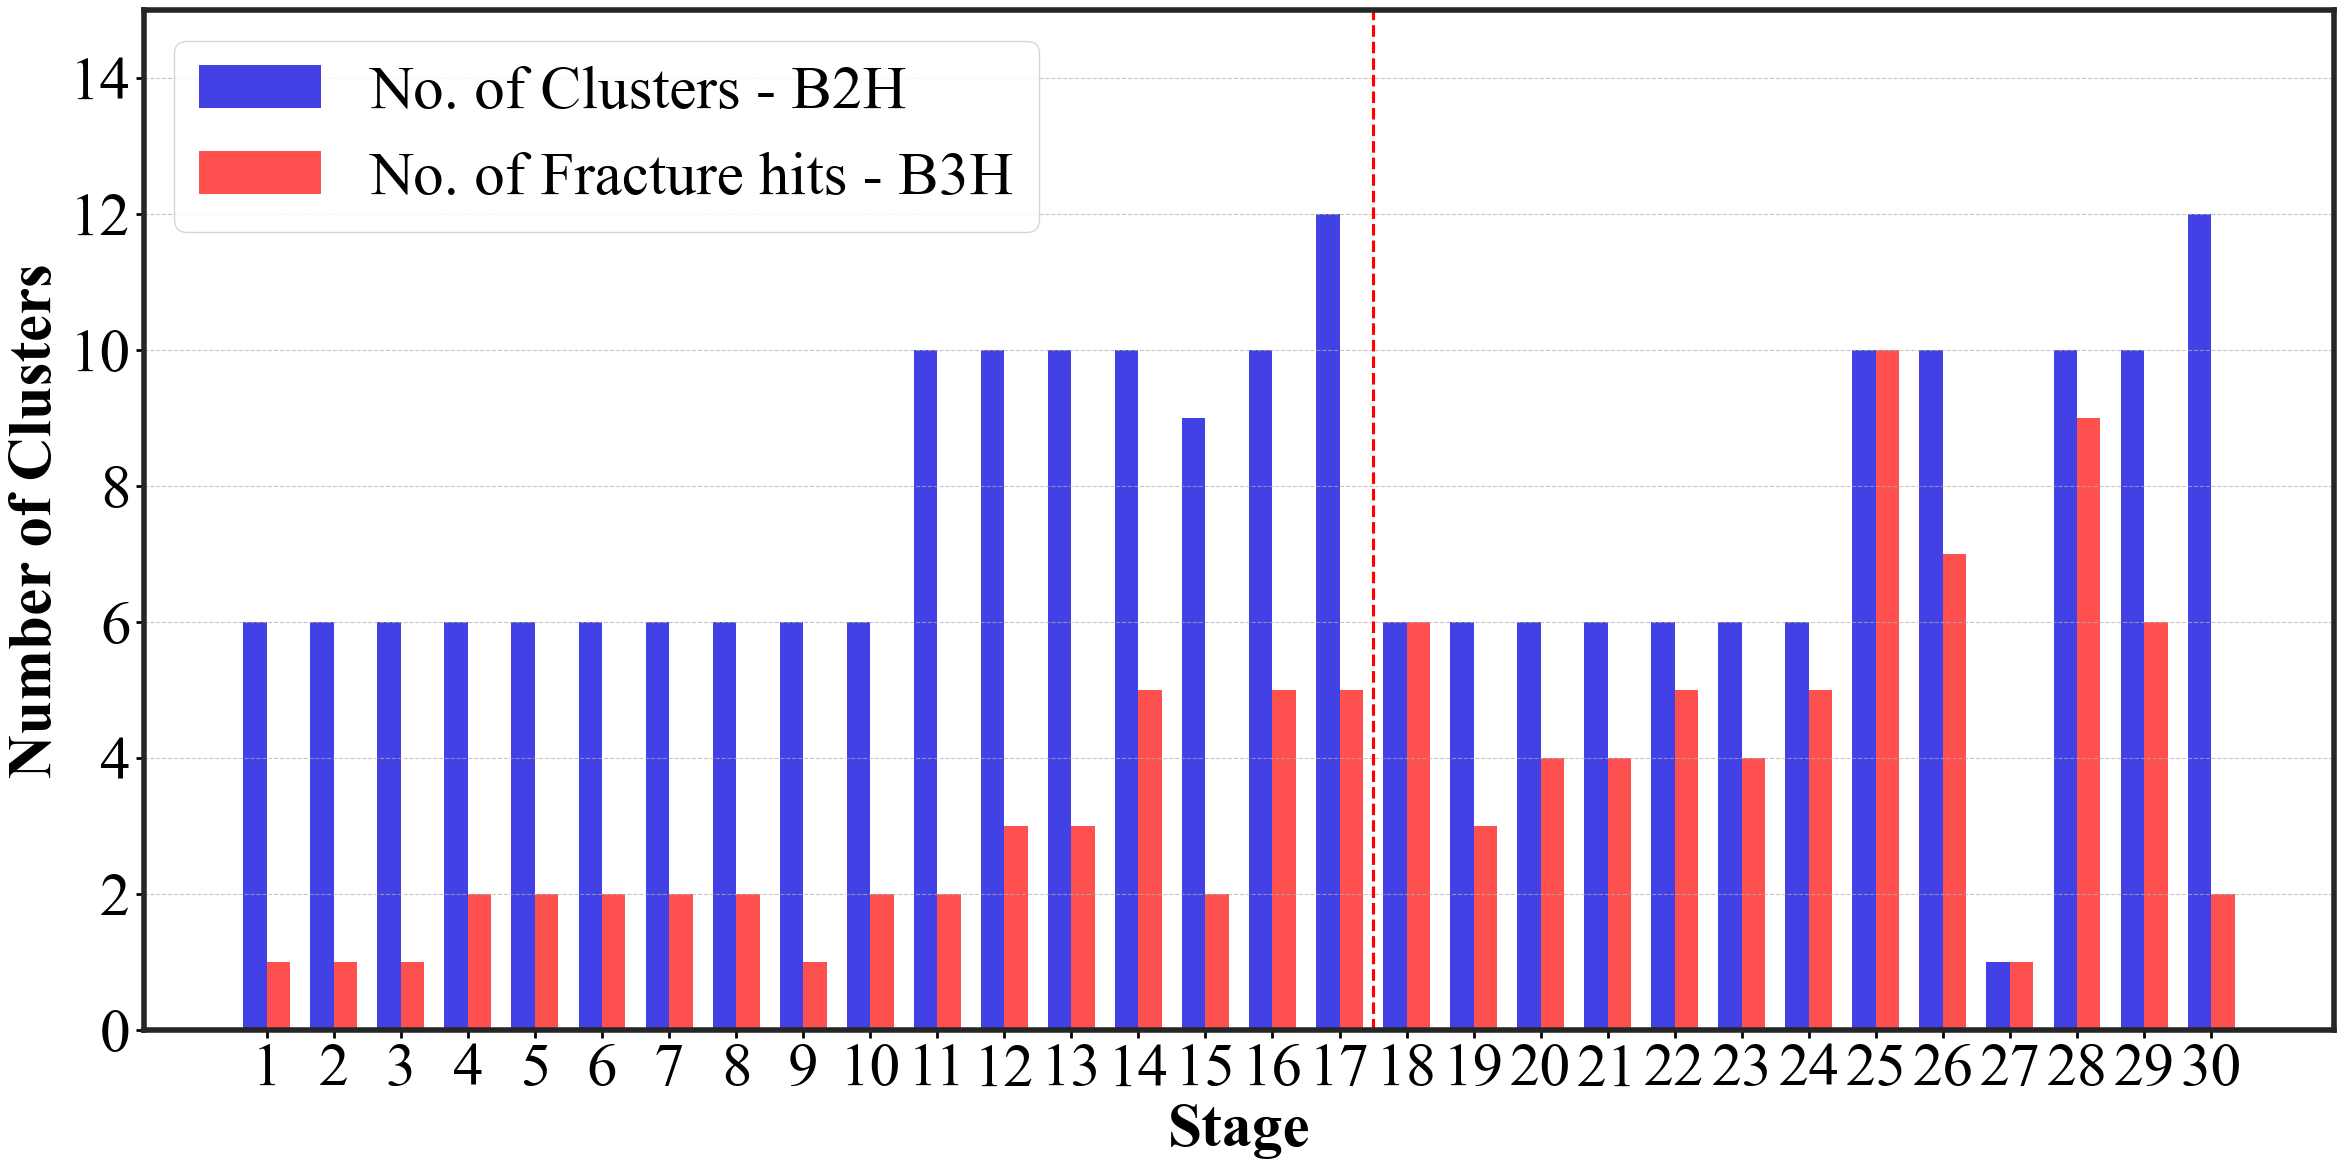

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
stages = np.arange(1, 31)
# 蓝色柱子：No. of Clusters - B2H
num_clusters = [
    6, 6, 6, 6, 6, 6, 6, 6, 6, 6,  # Stages 1-10
    10, 10, 10, 10, 9, 10, 12,     # Stages 11-17
    6, 6, 6, 6, 6, 6, 6,           # Stages 18-24
    10, 10, 1, 10, 10, 12          # Stages 25-30
]

# 橙色柱子：No. of Fracture hits - B3H
num_fracture_hits = [
    1, 1, 1, 2, 2, 2, 2, 2, 1, 2,  # Stages 1-10
    2, 3, 3, 5, 2, 5, 5, 6,        # Stages 11-18
    3, 4, 4, 5, 4, 5,              # Stages 19-24
    10, 7, 1, 9, 6, 2              # Stages 25-30
]

# 设置图形大小
plt.figure(figsize=(24,12))

# 设置柱宽和位置
bar_width = 0.35
x = np.arange(len(stages))

# 绘制柱状图
plt.bar(x - bar_width/2, num_clusters, width=bar_width, label='No. of Clusters - B2H', color="#4141E5")
plt.bar(x + bar_width/2, num_fracture_hits, width=bar_width, label='No. of Fracture hits - B3H', color='#FF5050')

# 添加分区线
plt.axvline(x=16.5, color='red', linestyle='--')  # Parent well impacted / not impacted

# 添加文本标签
# plt.text(7, 15, 'Parent well impacted', ha='center', va='center', fontsize=12)
# plt.text(23, 15, 'Parent well not impacted', ha='center', va='center', fontsize=12)

# 设置刻度和标签
plt.xticks(x, stages)
plt.xlabel('Stage')
plt.ylabel('Number of Clusters')
# plt.title('Frac hits at B3H during B2H treatment')
plt.legend()
plt.ylim(0,15)

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


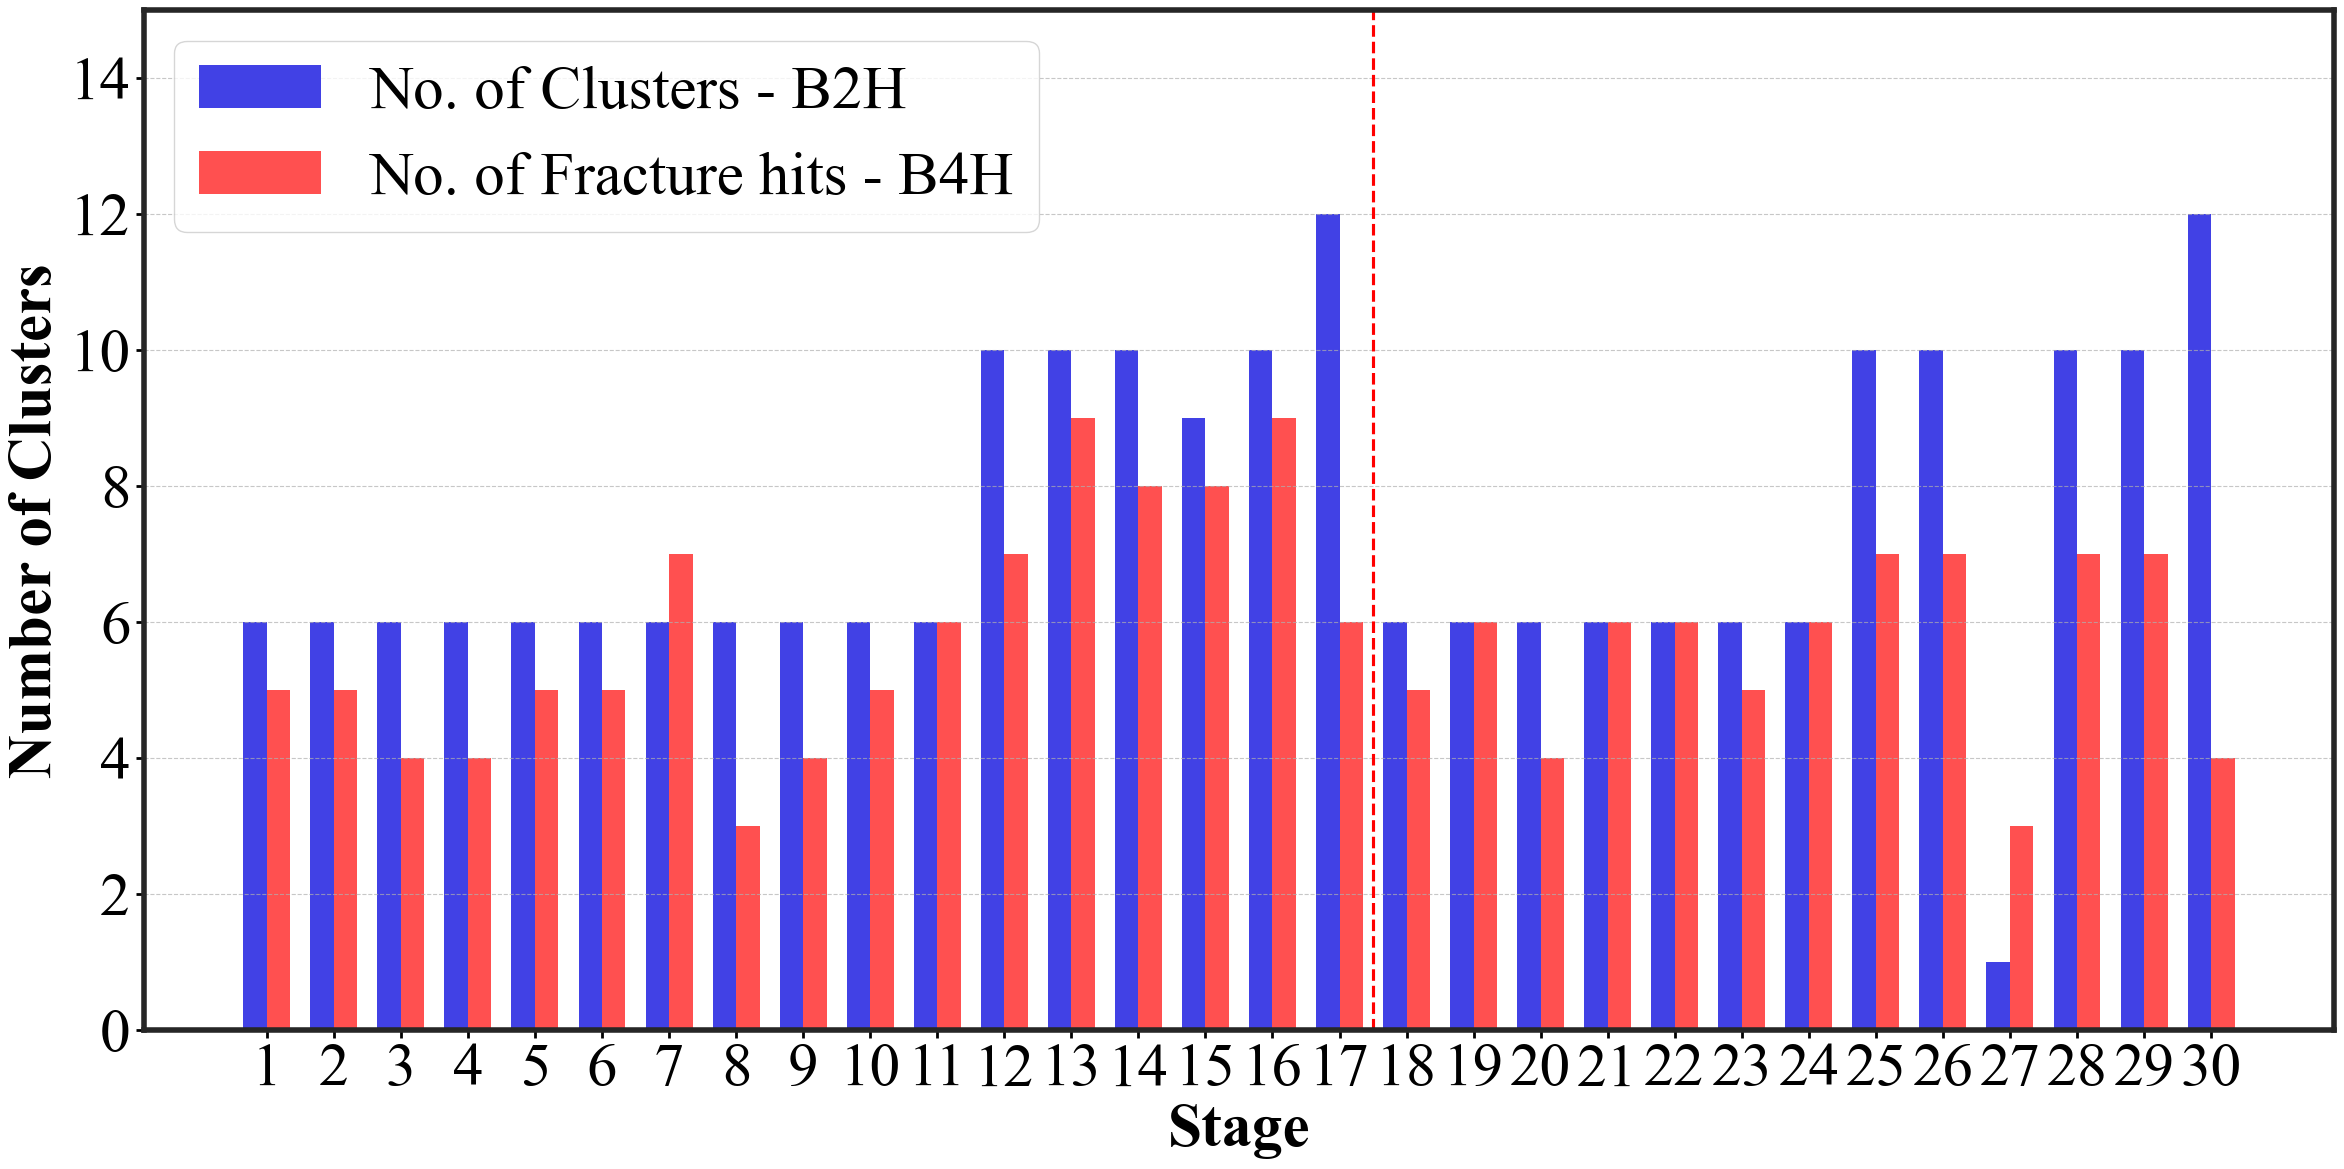

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
stages = np.arange(1, 31)
# Blue bars: No. of Clusters - B2H (Stage 1-30)
num_clusters = [
    6, 6, 6, 6, 6, 6, 6, 6, 6, 6,   # Stages 1-10
    6, 10, 10, 10, 9, 10, 12, 6, 6, 6, # Stages 11-20
    6, 6, 6, 6, 10, 10, 1, 10, 10, 12  # Stages 21-30
]

# Orange bars: No. of Fracture hits - B4H (Stage 1-30)
num_fracture_hits = [
    5, 5, 4, 4, 5, 5, 7, 3, 4, 5,   # Stages 1-10 (Stage 10 appears to be 0)
    6, 7, 9, 8, 8, 9, 6, 5, 6, 4,   # Stages 11-20 (Stage 19 appears to be 0)
    6, 6, 5, 6, 7, 7, 3, 7, 7, 4    # Stages 21-30 (Stage 21 appears to be 0)
]

# 设置图形大小
plt.figure(figsize=(24,12))

# 设置柱宽和位置
bar_width = 0.35
x = np.arange(len(stages))

# 绘制柱状图
plt.bar(x - bar_width/2, num_clusters, width=bar_width, label='No. of Clusters - B2H', color="#4141E5")
plt.bar(x + bar_width/2, num_fracture_hits, width=bar_width, label='No. of Fracture hits - B4H', color='#FF5050')

# 添加分区线
plt.axvline(x=16.5, color='red', linestyle='--')  # Parent well impacted / not impacted

# 添加文本标签
# plt.text(7, 15, 'Parent well impacted', ha='center', va='center', fontsize=12)
# plt.text(23, 15, 'Parent well not impacted', ha='center', va='center', fontsize=12)

# 设置刻度和标签
plt.xticks(x, stages)
plt.xlabel('Stage')
plt.ylabel('Number of Clusters')
# plt.title('Frac hits at B3H during B2H treatment')
plt.legend()
plt.ylim(0,15)

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


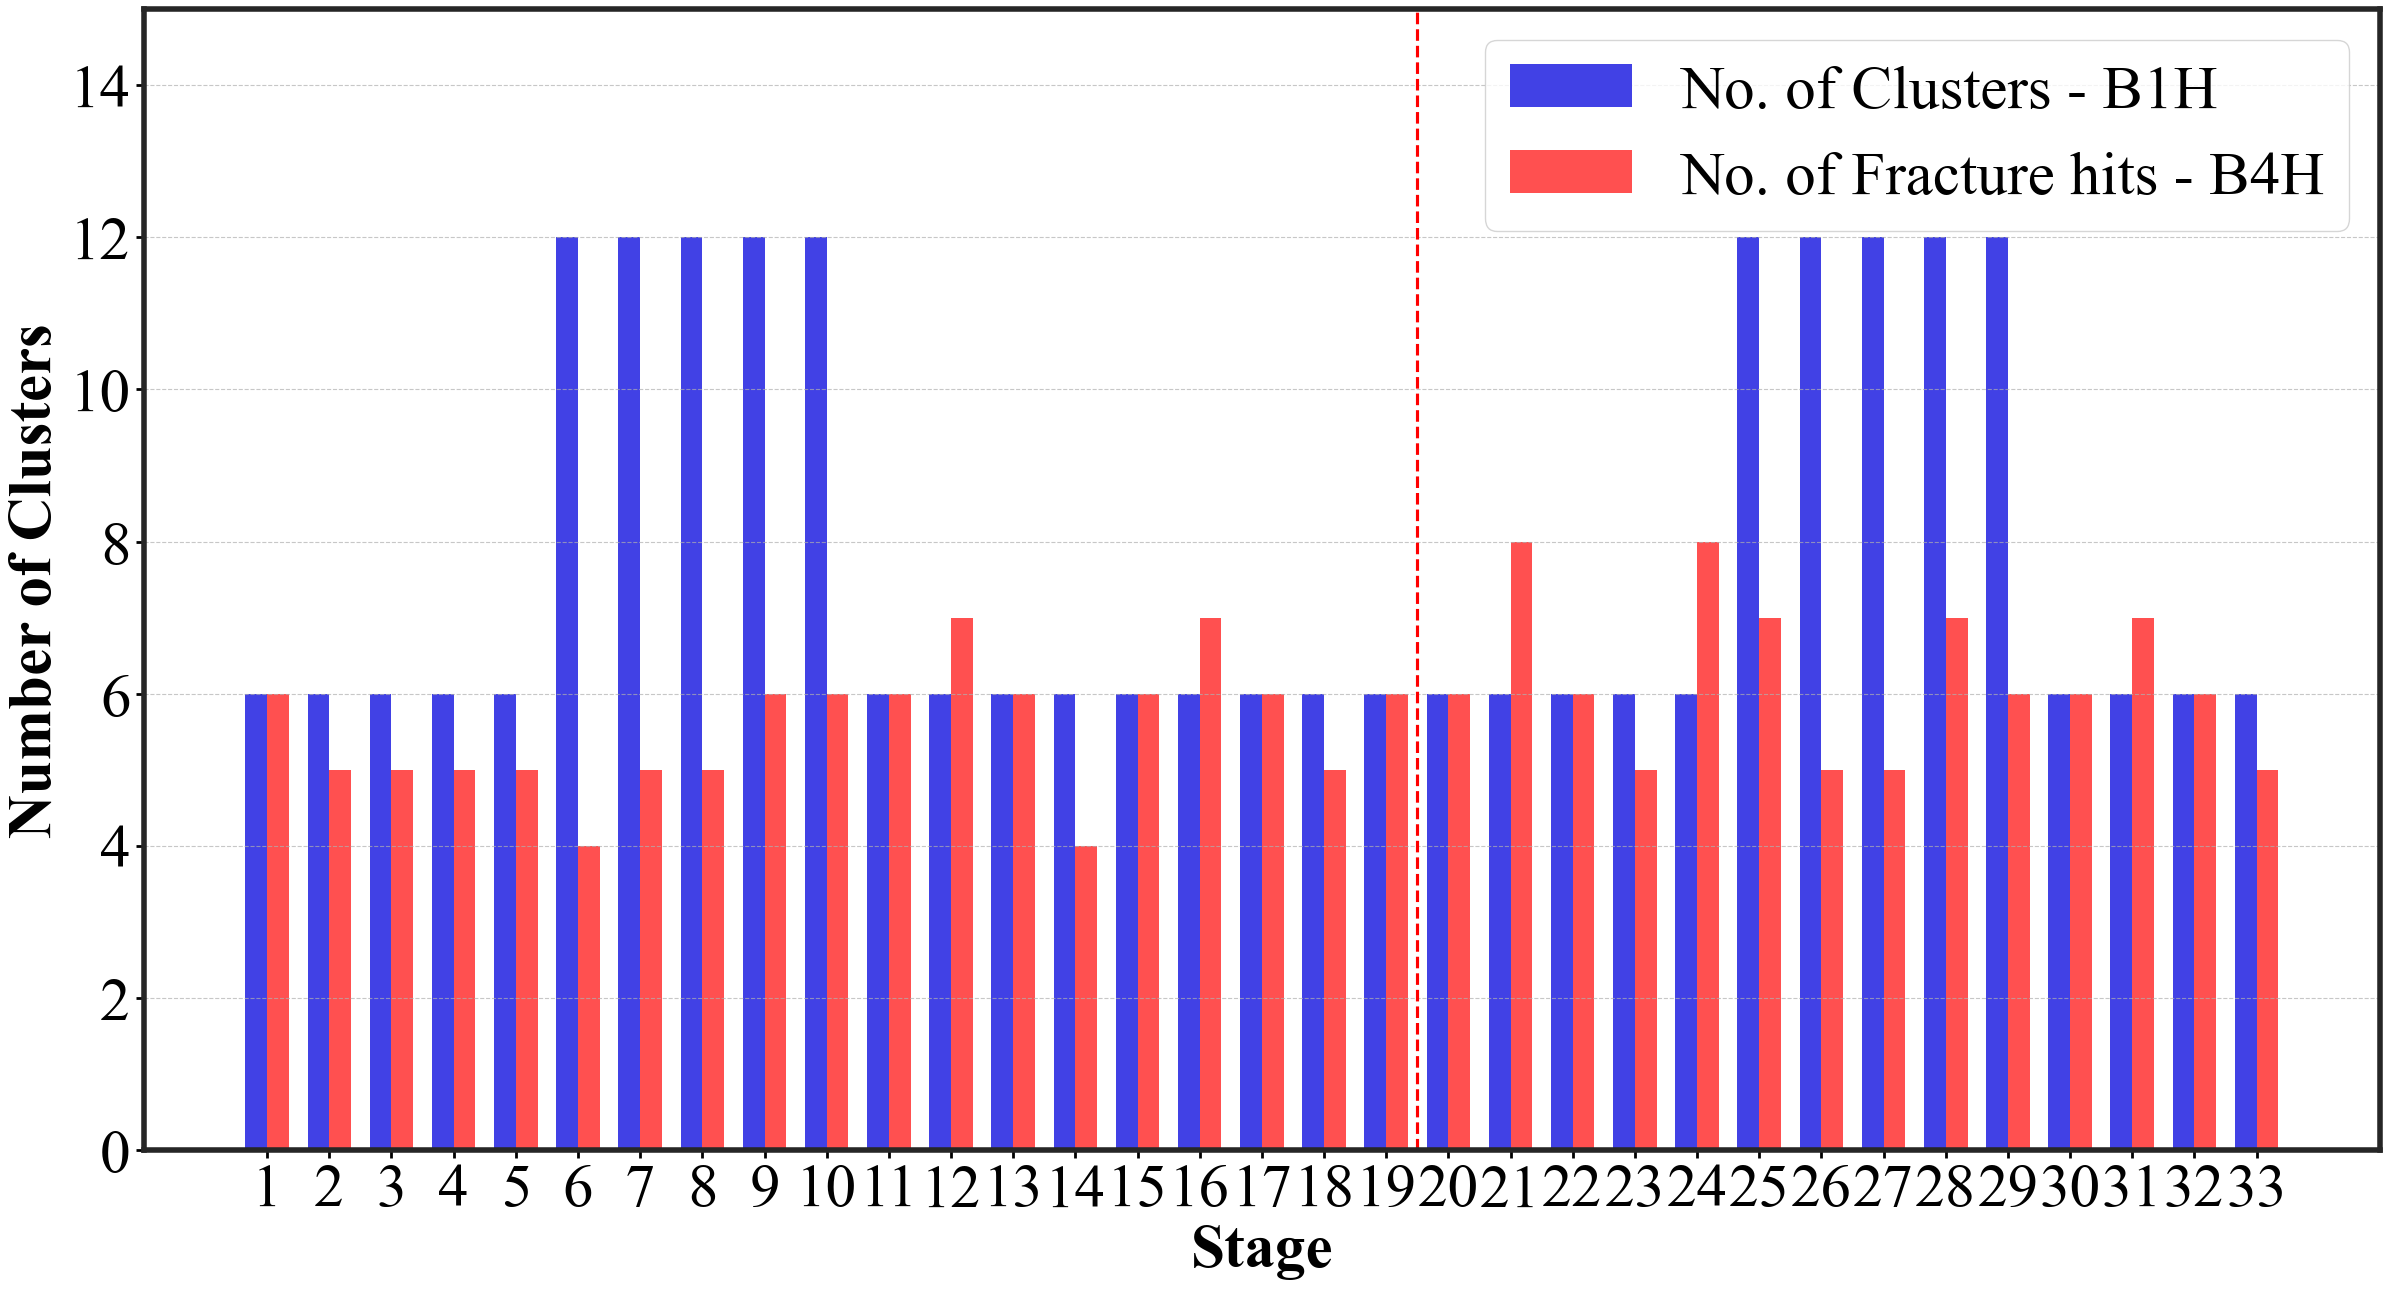

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
stages = np.arange(1, 34)
# Blue bars: No. of Clusters - B2H (Stage 1-30)
# Blue bars: No. of Clusters - B1H (Stages 1-33)
num_clusters = [
    6, 6, 6, 6, 6,              # Stages 1-5
    12, 12, 12, 12, 12,     # Stages 6-11
    6, 6, 6, 6, 6,
    6, 6, 6, 6, 6,
    6, 6, 6, 6,             # Stages 12-24
    12, 12, 12, 12, 12,         # Stages 25-29
    6, 6, 6, 6                  # Stages 30-33
]

# Orange bars: No. of Fracture hits - B4H (Stages 1-33)
num_fracture_hits = [
    6, 5, 5, 5, 5,              # Stages 1-5
    4, 5, 5, 6, 6,           # Stages 6-11 (Stage 10 appears to be 0)
    6, 7, 6, 4, 6, 
    7, 6, 5, 6, 6, 8, 6, 5, 8,           # Stages 19-24
    7, 5, 5, 7, 6,              # Stages 25-29
    6, 7, 6, 5                  # Stages 30-33
]

# 设置图形大小
plt.figure(figsize=(24,13))

# 设置柱宽和位置
bar_width = 0.35
x = np.arange(len(stages))

# 绘制柱状图
plt.bar(x - bar_width/2, num_clusters, width=bar_width, label='No. of Clusters - B1H', color="#4141E5")
plt.bar(x + bar_width/2, num_fracture_hits, width=bar_width, label='No. of Fracture hits - B4H', color='#FF5050')

# 添加分区线
plt.axvline(x=18.5, color='red', linestyle='--')  # Parent well impacted / not impacted

# 添加文本标签
# plt.text(7, 15, 'Parent well impacted', ha='center', va='center', fontsize=12)
# plt.text(23, 15, 'Parent well not impacted', ha='center', va='center', fontsize=12)

# 设置刻度和标签
plt.xticks(x, stages)
plt.xlabel('Stage')
plt.ylabel('Number of Clusters')
# plt.title('Frac hits at B3H during B2H treatment')
plt.legend(ncol=1)
plt.ylim(0,15)

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# EVO7

In [4]:

# Figure format
rc = {'axes.facecolor':'white',
      'figure.figsize': (12, 6),
      'savefig.dpi': 600,
#       'axes.grid' : False,
      'axes.edgecolor' : '0.15',
      
      'font.family':'Times New Roman',
      'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],  # 备选
      # —— 数学字体（$...$ 内）——
      'mathtext.fontset': 'stix',     # 关键：让 μ、ε 等用 STIX（Times 风格）
      'axes.unicode_minus': False,    # 让负号显示为正常的连字符


      'axes.labelsize': 20,         # X、Y 轴标题字体
      'axes.labelweight': 'bold',   # X、Y 轴标题加粗
      'xtick.labelsize': 20,        # X轴刻度文字
      'ytick.labelsize': 20,        # Y轴刻度文字
      'legend.fontsize': 20,       # 图例字体

      # 线宽与颜色顺序
      'lines.linewidth': 2.25,      # 所有线条默认 2.25 pt
      'axes.prop_cycle': cycler('color', list(('k', 'r', 'b', 'g', 'm', 'c', 'y'))),

      # 刻度朝外 & 粗细
      'xtick.direction': 'out',
      'ytick.direction': 'out',
      'xtick.major.size': 6,
      'ytick.major.size': 6,
      'xtick.major.width': 2.0,
      'ytick.major.width': 2.0,

      # 坐标轴（内框）线宽
      'axes.linewidth': 2.0,
      } 
# lack of font size
plt.rcParams.update(rc)

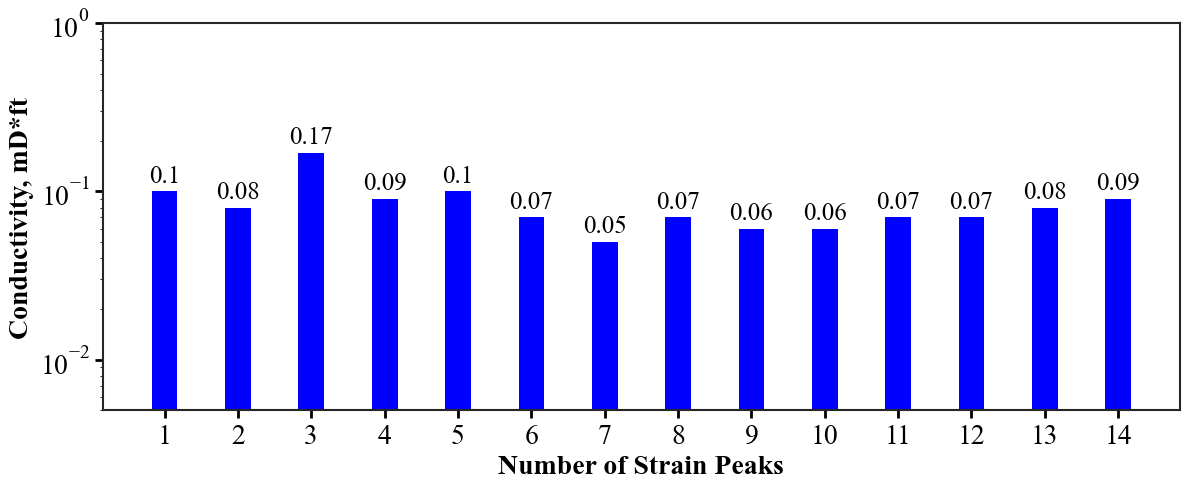

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 你的数据
# before 2026 march quaterly update, 18 values
# values = np.array([
#     0.10, 0.08, 0.21, 0.19, 0.008, 0.17, 0.13, 0.09, 0.10,
#     0.07, 0.05, 0.02, 0.07, 0.06, 0.06, 0.07, 0.07, 0.09
# ])

# delete 5,7,12; separate 17 into 2 values; ignore 3,4 (new fracture only exist in evo7)
values = np.array([
0.10,   #1
0.08,   #2
# 0.21,   #3
# 0.19,   #4
# 0.008,  #5
0.17,   #6
# 0.13,   #7
0.09,   #8
0.10,   #9
0.07,   #10
0.05,   #11
# 0.02,   #12
0.07,   #13
0.06,   #14
0.06,   #15
0.07,   #16
0.07,   #17a
0.08,   #17b
0.09,   #18
])

# x 轴
x = np.arange(1, len(values)+1)

# 画图
fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(x, values, color='blue', width=0.35)

# 对数坐标
ax.set_yscale('log')

# 轴标签
ax.set_xlabel("Number of Strain Peaks")
ax.set_ylabel("Conductivity, mD*ft",)

# x 轴刻度
ax.set_xticks(x)
ax.set_ylim(0.005, 1)  # 根据你的数据范围调整


# 在柱子上标数值
for xi, yi in zip(x, values):
    ax.text(
        xi, yi*1.05,
        f"{yi:.3f}".rstrip('0').rstrip('.'),
        ha='center',
        va='bottom',
        fontsize=18
    )

# 边框加粗（和你图类似）
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [6]:

0.10,   #1
0.08,   #2
# 0.21,   #3
# 0.19,   #4
# 0.008,  #5
0.17,   #6
# 0.13,   #7
0.09,   #8
0.10,   #9
0.07,   #10
0.05,   #11
# 0.02,   #12
0.07,   #13
0.06,   #14
0.06,   #15
0.07,   #16
0.07,   #17a
0.08,   #17b
0.09,   #18


(0.09,)

# 0-width


## Evo 5 and Evo 7

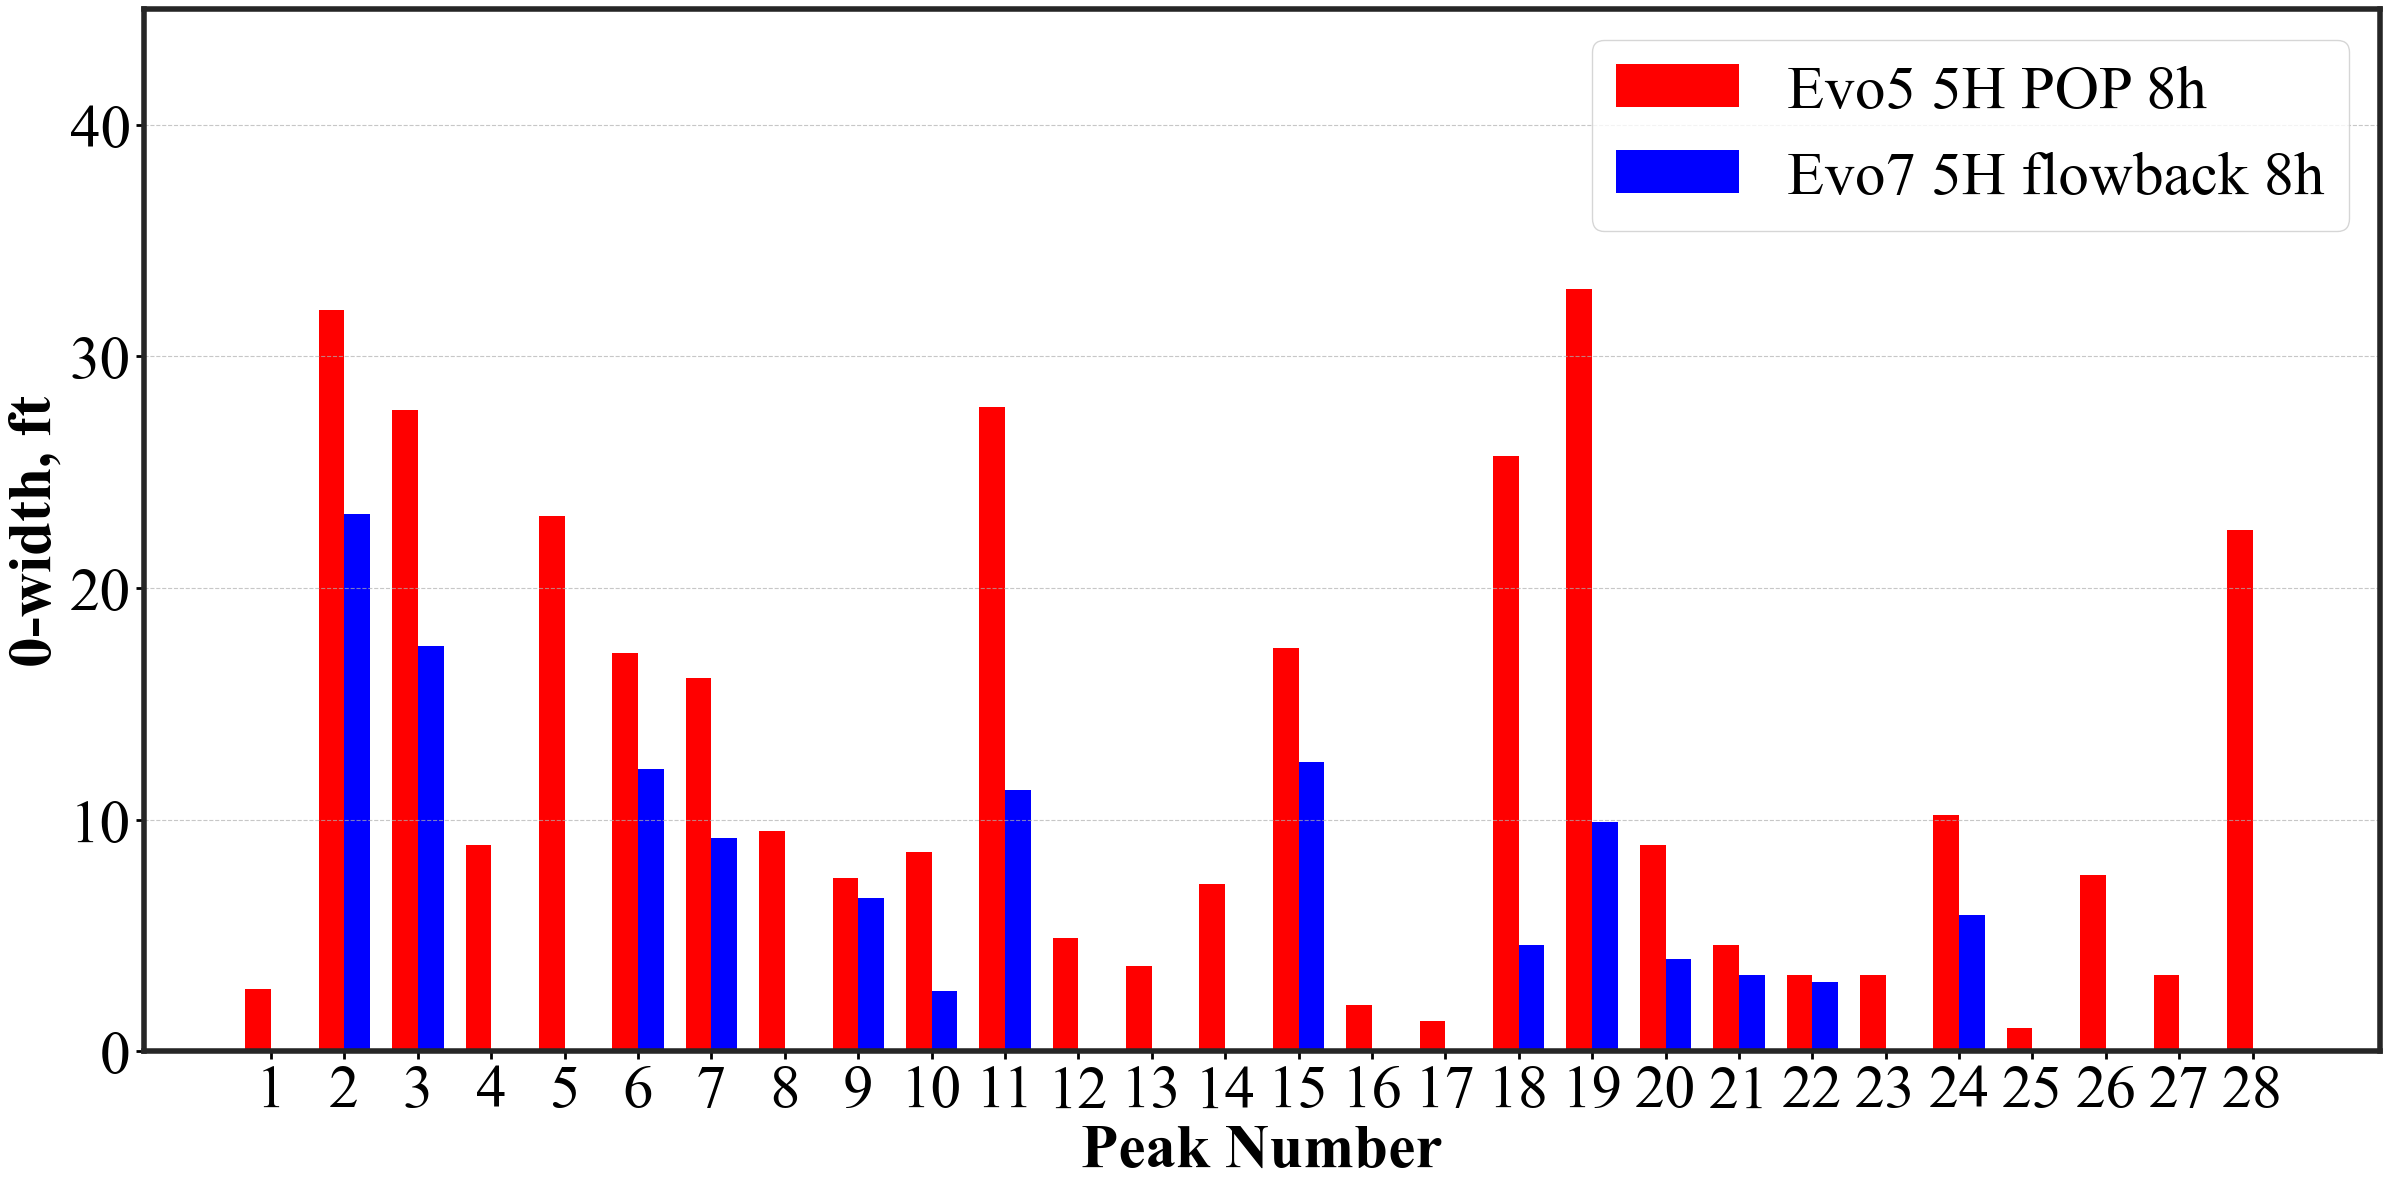

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
peaks = np.arange(1, 29)
# 蓝色柱子：
width_evo5 = [
    2.7 , 32, 27.7, 8.9, 23.1, 17.2, 16.1, 9.5, 7.5, 8.6,        # peaks 1-10
    27.8, 4.9, 3.7, 7.2, 17.4, 2, 1.3, 25.7, 32.9, 8.9,        # peaks 11-20
    4.6, 3.3, 3.3, 10.2, 1, 7.6, 3.3, 22.5
]

# 橙色柱子：
width_evo7 = [
    0, 23.2, 17.5, 0, 0, 12.2, 9.2, 0, 6.6, 2.6,    # peaks 1-10
    11.3, 0, 0, 0, 12.5, 0, 0, 4.6, 9.9, 4,         # peaks 11-20
    3.3, 3, 0, 5.9, 0, 0, 0, 0
]

# 设置图形大小
plt.figure(figsize=(24,12))

# 设置柱宽和位置
bar_width = 0.35
x = np.arange(len(peaks))

# 绘制柱状图
plt.bar(x - bar_width/2, width_evo5, width=bar_width, label='Evo5 5H POP 8h', color='red')
plt.bar(x + bar_width/2, width_evo7, width=bar_width, label='Evo7 5H flowback 8h', color="#0000FF")

# 添加分区线
# plt.axvline(x=16.5, color='red', linestyle='--')  # Parent well impacted / not impacted

# 添加文本标签
# plt.text(7, 15, 'Parent well impacted', ha='center', va='center', fontsize=12)
# plt.text(23, 15, 'Parent well not impacted', ha='center', va='center', fontsize=12)

# 设置刻度和标签
plt.xticks(x, peaks)
plt.xlabel('Peak Number')
plt.ylabel('0-width, ft')
# plt.title('Frac hits at B3H during B2H treatment')
plt.legend()
plt.ylim(0,45)
plt.yticks(np.arange(0, 41, 10))

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plot/0-width_bar_figure.png')
plt.show()



## Evo 5 and Evo6 and Evo 7

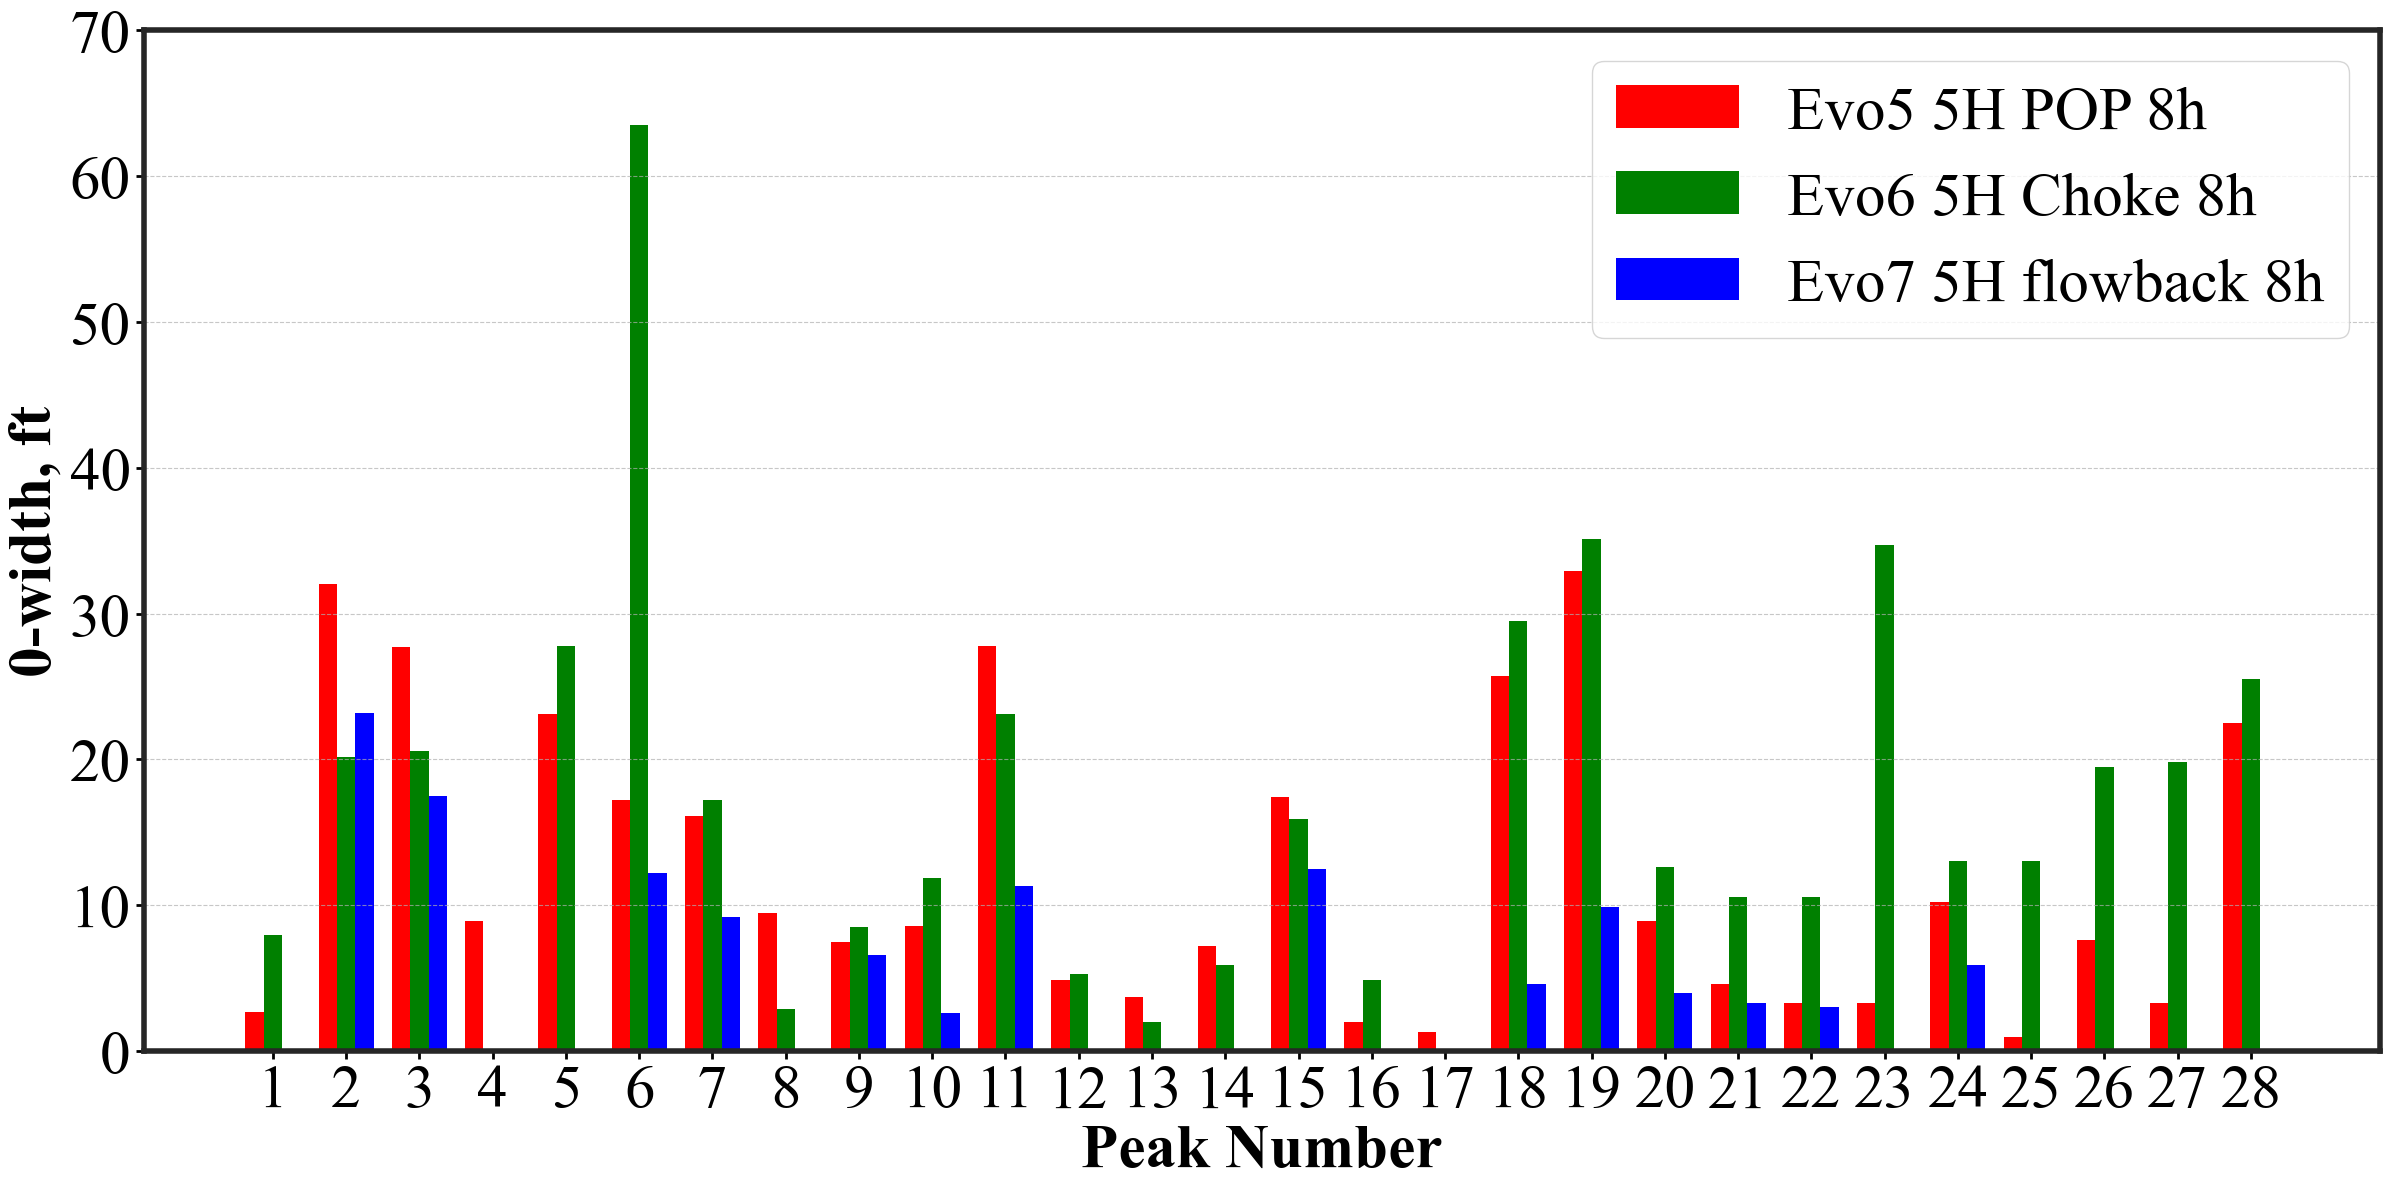

In [19]:
from turtle import width

import matplotlib.pyplot as plt
import numpy as np

# 数据
peaks = np.arange(1, 29)
# red 柱子：
width_evo5 = [
    2.7 , 32, 27.7, 8.9, 23.1, 17.2, 16.1, 9.5, 7.5, 8.6,        # peaks 1-10
    27.8, 4.9, 3.7, 7.2, 17.4, 2, 1.3, 25.7, 32.9, 8.9,        # peaks 11-20
    4.6, 3.3, 3.3, 10.2, 1, 7.6, 3.3, 22.5
]

width_evo6 = [
    8.0, 20.2, 20.6, 0, 27.8, 
    63.5, 17.2, 2.9, 8.5, 11.9,
    23.1, 5.3, 2.0, 5.9, 15.9,
    4.9, 0, 29.5, 35.1, 12.6, 
    21.2/2, 21.2/2, 34.7, 26.1/2, 26.1/2,
    19.5, 19.8, 25.5 ]



# blue 柱子：
width_evo7 = [
    0, 23.2, 17.5, 0, 0, 12.2, 9.2, 0, 6.6, 2.6,    # peaks 1-10
    11.3, 0, 0, 0, 12.5, 0, 0, 4.6, 9.9, 4,         # peaks 11-20
    3.3, 3, 0, 5.9, 0, 0, 0, 0
]


# 设置图形大小
plt.figure(figsize=(24, 12))

# 设置柱宽和位置
bar_width = 0.25      # 每根柱子的宽度
group_spacing = 1  # 每个 peak index 之间的距离

x = np.arange(len(peaks)) * group_spacing

# 绘制三组柱状图
plt.bar(x - bar_width, width_evo5, width=bar_width, label='Evo5 5H POP 8h', color='red')
plt.bar(x,             width_evo6, width=bar_width, label='Evo6 5H Choke 8h', color='green')
plt.bar(x + bar_width, width_evo7, width=bar_width, label='Evo7 5H flowback 8h', color='blue')

# 设置刻度和标签
plt.xticks(x, peaks)
plt.xlabel('Peak Number')
plt.ylabel('0-width, ft')

# 图例
plt.legend()

# y轴范围和刻度
plt.ylim(0, 70)
plt.yticks(np.arange(0, 71, 10))

# 网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plot/0-width_bar_figure.png', dpi=300)
plt.show()


# magnitude

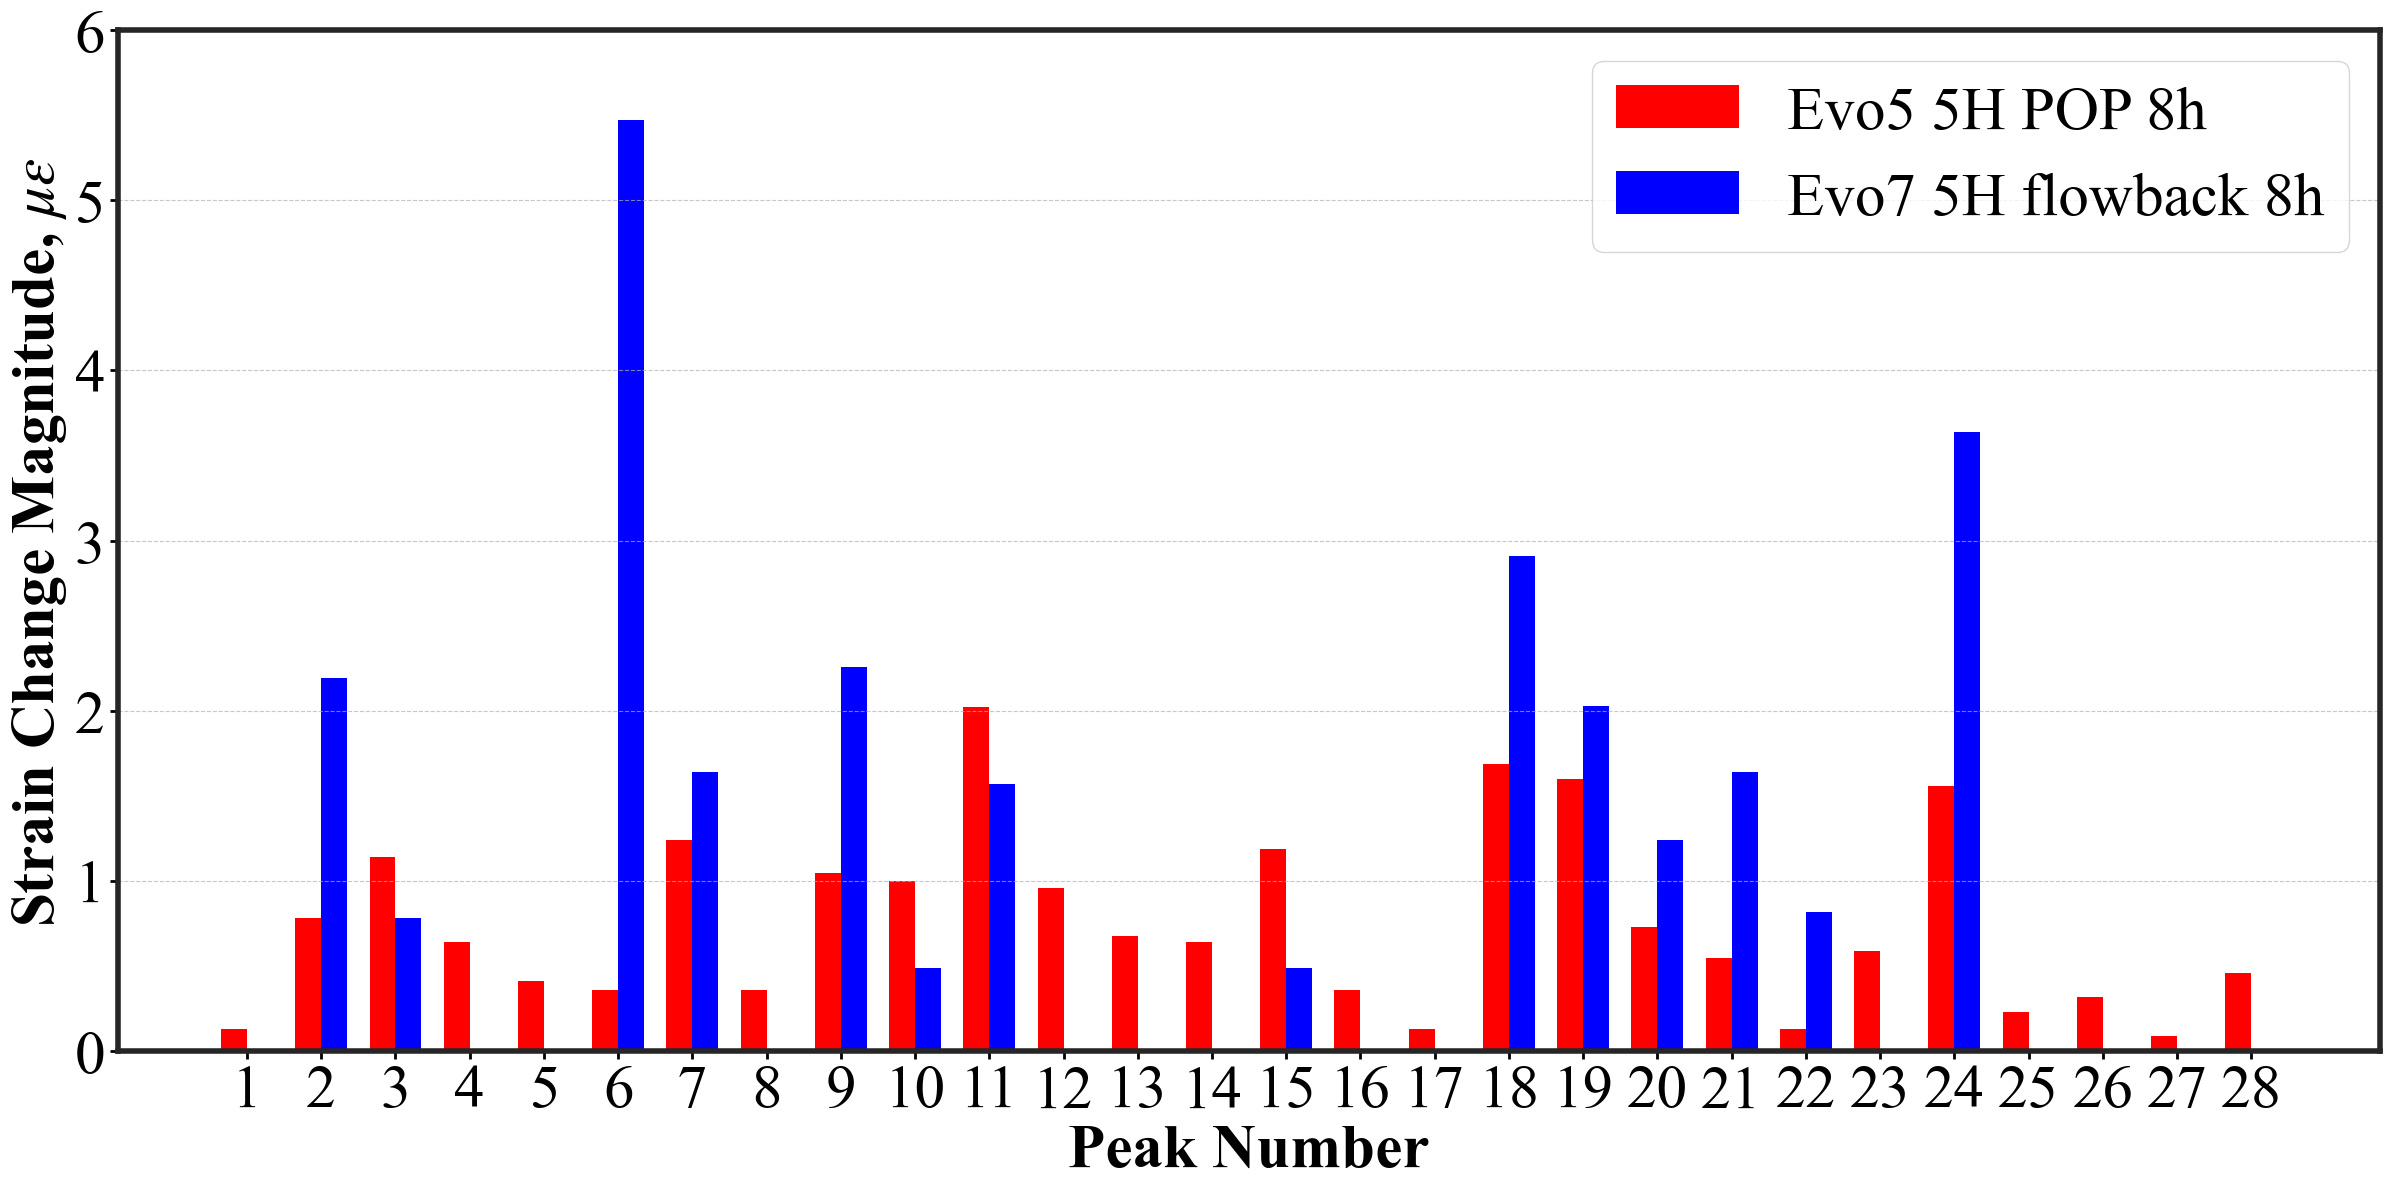

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
peaks = np.arange(1, 29)
# 蓝色柱子：
width_evo5 = [
    0.13, 0.78, 1.14, 0.64, 0.41, 0.36, 1.24, 0.36, 1.05, 1.00,        # peaks 1-10
    2.02, 0.96, 0.68, 0.64, 1.19, 0.36, 0.13, 1.69, 1.60, 0.73,        # peaks 11-20
    0.55, 0.13, 0.59, 1.56, 0.23, 0.32, 0.09, 0.46
]

# 橙色柱子：
width_evo7 = [
    0.00, 2.19, 0.78, 0.00, 0.00, 5.47, 1.64, 0.00, 2.26, 0.49,    # peaks 1-10
    1.57, 0.00, 0.00, 0.00, 0.49, 0.00, 0.00, 2.91, 2.03, 1.24,         # peaks 11-20
    1.64, 0.82, 0.00, 3.64, 0.00, 0.00, 0.00, 0.00
]

# 设置图形大小
plt.figure(figsize=(24,12))

# 设置柱宽和位置
bar_width = 0.35
x = np.arange(len(peaks))

# 绘制柱状图
plt.bar(x - bar_width/2, width_evo5, width=bar_width, label='Evo5 5H POP 8h', color='red')
plt.bar(x + bar_width/2, width_evo7, width=bar_width, label='Evo7 5H flowback 8h', color="#0000FF")

# 添加分区线
# plt.axvline(x=16.5, color='red', linestyle='--')  # Parent well impacted / not impacted

# 添加文本标签
# plt.text(7, 15, 'Parent well impacted', ha='center', va='center', fontsize=12)
# plt.text(23, 15, 'Parent well not impacted', ha='center', va='center', fontsize=12)

# 设置刻度和标签
plt.xticks(x, peaks)
plt.xlabel('Peak Number')
plt.ylabel(r'Strain Change Magnitude, $\mu\varepsilon$')
# plt.title('Frac hits at B3H during B2H treatment')
plt.legend()
plt.ylim(0,5)
plt.yticks(np.arange(0, 7, 1))

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plot/magnitude_bar_figure.png')
plt.show()



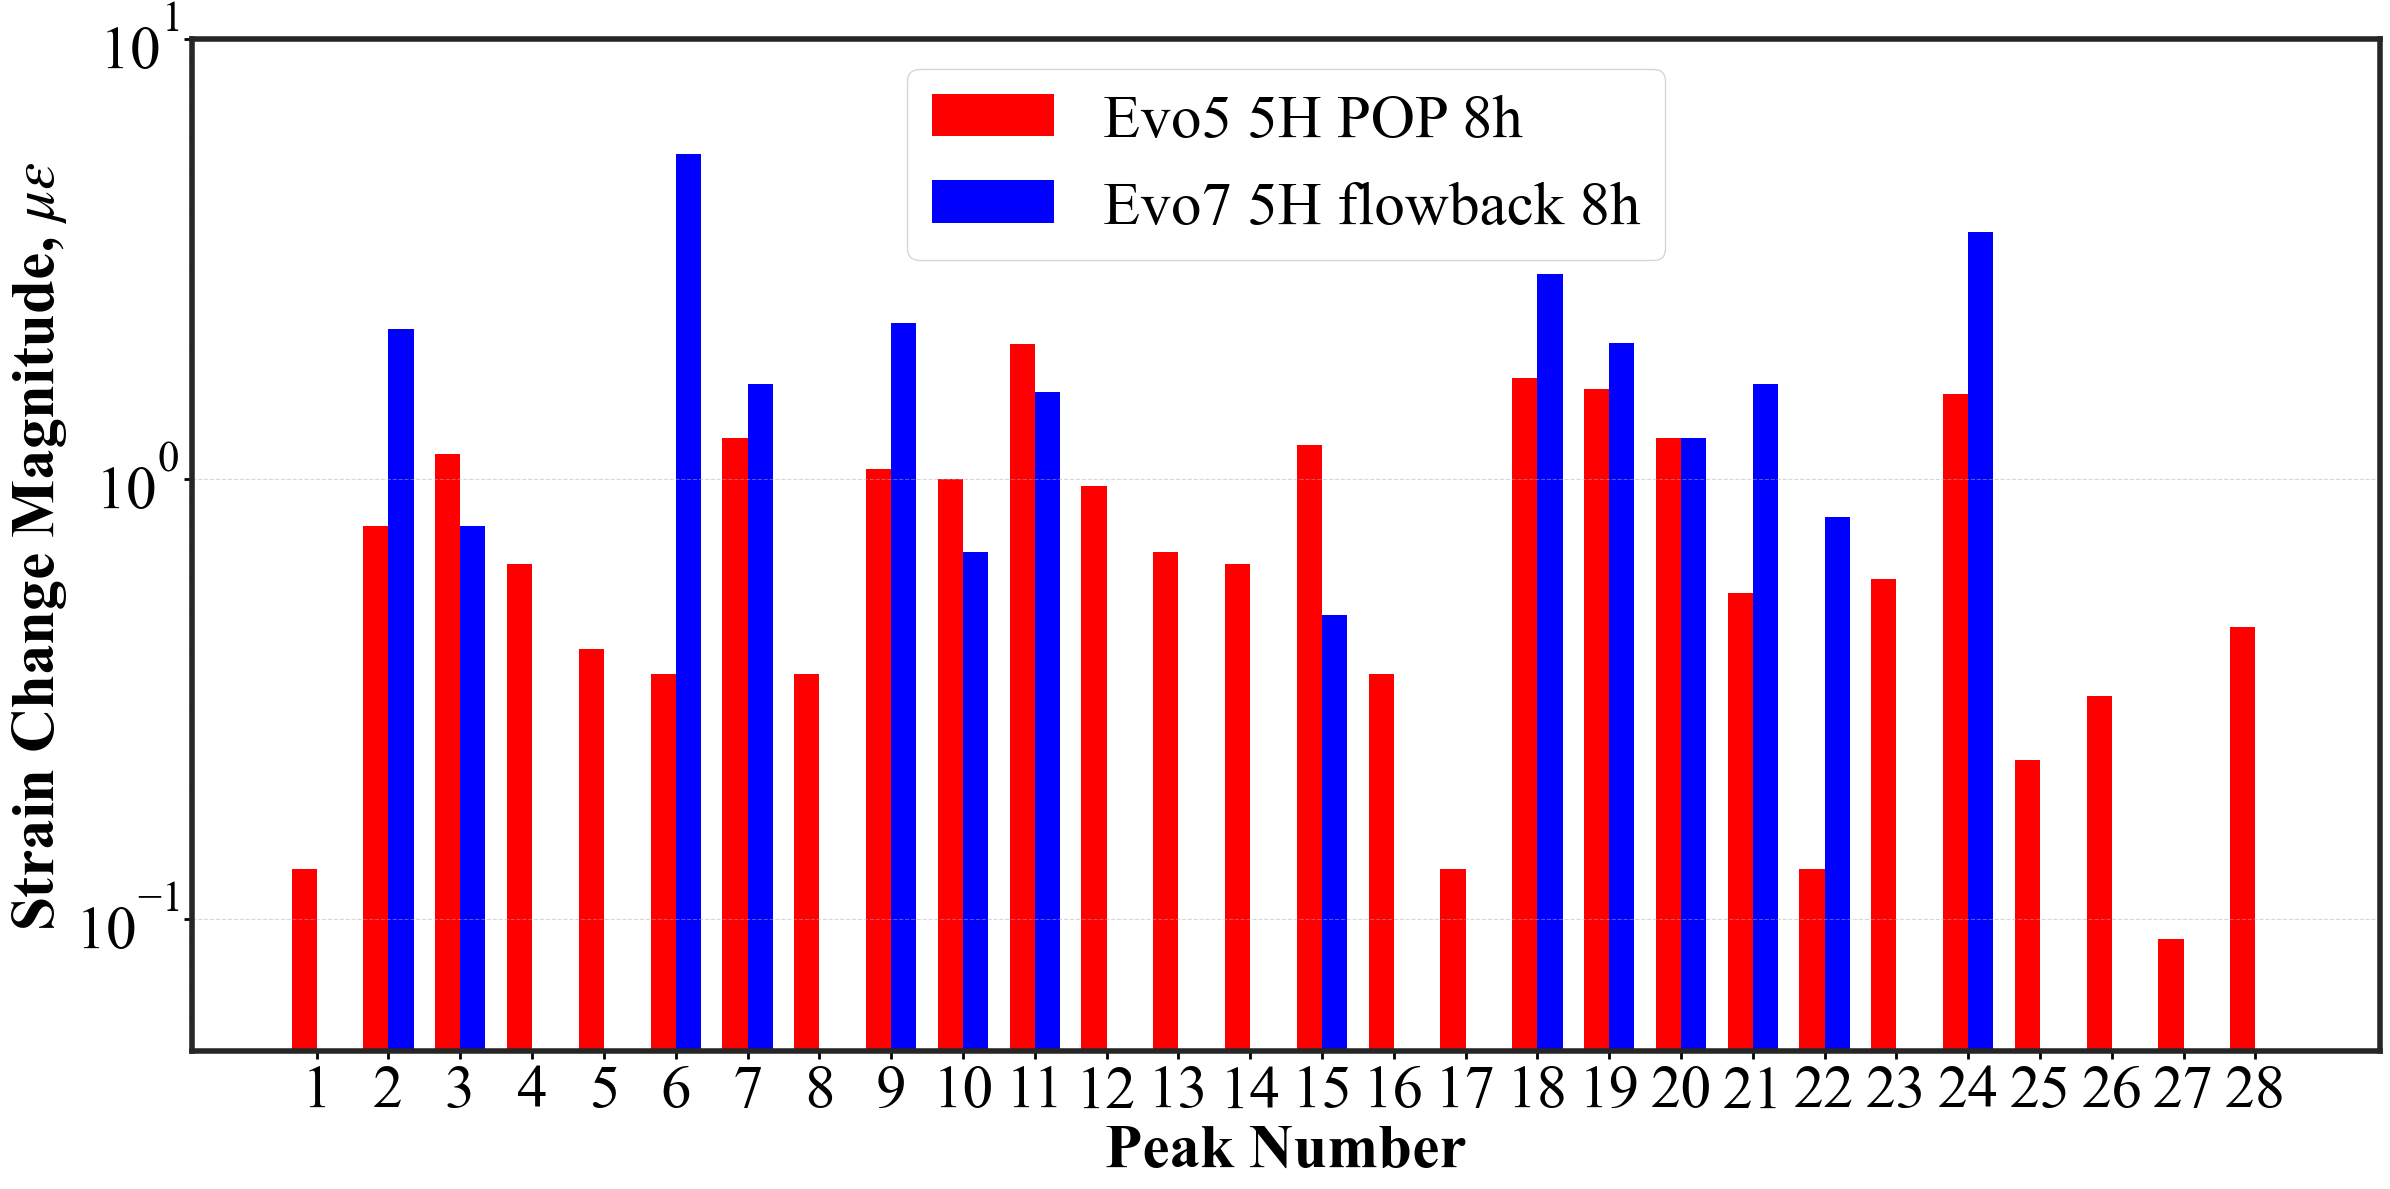

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ======================
# 数据
# ======================
peaks = np.arange(1, 29)

width_evo5 = [
    0.13, 0.78, 1.14, 0.64, 0.41, 0.36, 1.24, 0.36, 1.05, 1.00,
    2.02, 0.96, 0.68, 0.64, 1.19, 0.36, 0.13, 1.69, 1.60, 1.24,
    0.55, 0.13, 0.59, 1.56, 0.23, 0.32, 0.09, 0.46
]

width_evo7 = [
    0.00, 2.19, 0.78, 0.00, 0.00, 5.47, 1.64, 0.00, 2.26, 0.68,
    1.57, 0.00, 0.00, 0.00, 0.49, 0.00, 0.00, 2.91, 2.03, 1.24,
    1.64, 0.82, 0.00, 3.64, 0.00, 0.00, 0.00, 0.00
]

# ======================
# 处理0（log不能有0）
# ======================
eps = 0.05   # 你可以调小一点，比如 0.01
width_evo5_plot = [max(v, eps) for v in width_evo5]
width_evo7_plot = [max(v, eps) for v in width_evo7]

# ======================
# 画图
# ======================
plt.figure(figsize=(24, 12))

bar_width = 0.35
x = np.arange(len(peaks))

plt.bar(x - bar_width/2, width_evo5_plot, width=bar_width,
        label='Evo5 5H POP 8h', color='red')

plt.bar(x + bar_width/2, width_evo7_plot, width=bar_width,
        label='Evo7 5H flowback 8h', color='blue')

# ======================
# log scale
# ======================
plt.yscale('log')
plt.ylim(0.05, 10)

# ======================
# 坐标 & 标签
# ======================
plt.xticks(x, peaks)
plt.xlabel('Peak Number')
plt.ylabel(r'Strain Change Magnitude, $\mu\varepsilon$')

# 网格（log下建议用细一点）
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()

# Conductivity

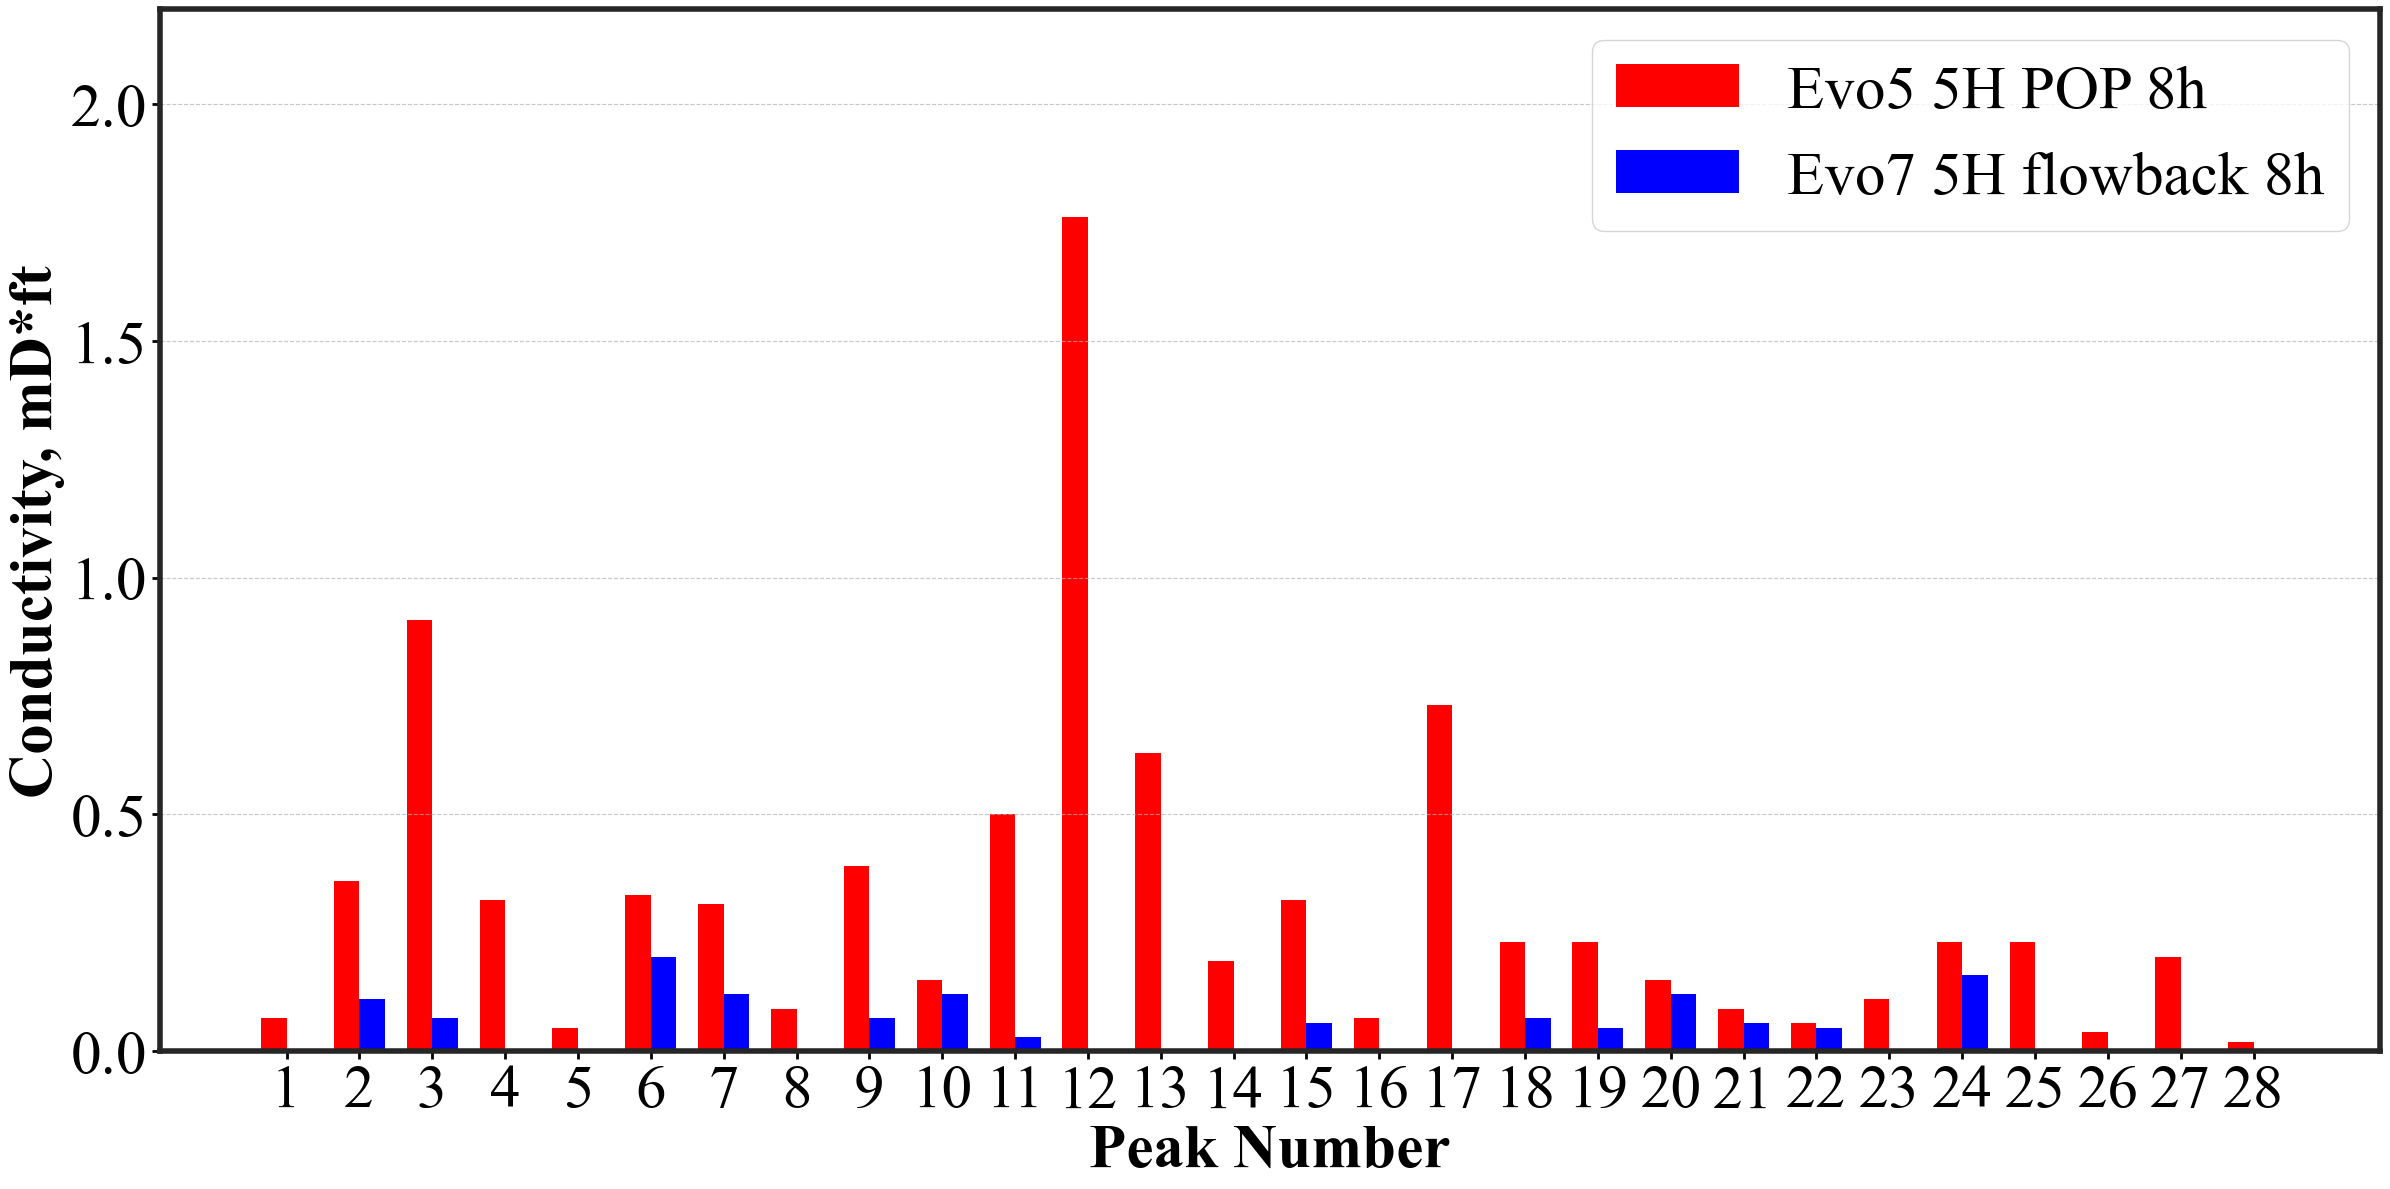

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
peaks = np.arange(1, 29)
# 蓝色柱子：
width_evo5 = [
    0.07, 0.36, 0.91, 0.32, 0.05, 0.33, 0.31, 0.09, 0.39, 0.15,       # peaks 1-10
    0.50, 1.76, 0.63, 0.19, 0.32, 0.07, 0.73, 0.23, 0.23, 0.15,       # peaks 11-20
    0.09, 0.06, 0.11, 0.23, 0.23, 0.04, 0.20, 0.02
]

# 橙色柱子：
width_evo7 = [
    0.00, 0.11, 0.07, 0.00, 0.00, 0.20, 0.12, 0.00, 0.07, 0.12,    # peaks 1-10
    0.03, 0.00, 0.00, 0.00, 0.06, 0.00, 0.00, 0.07, 0.05, 0.12,         # peaks 11-20
    0.06, 0.05, 0.00, 0.16, 0.00, 0.00, 0.00, 0.00
]

# 设置图形大小
plt.figure(figsize=(24,12))

# 设置柱宽和位置
bar_width = 0.35
x = np.arange(len(peaks))

# 绘制柱状图
plt.bar(x - bar_width/2, width_evo5, width=bar_width, label='Evo5 5H POP 8h', color='red')
plt.bar(x + bar_width/2, width_evo7, width=bar_width, label='Evo7 5H flowback 8h', color="#0000FF")

# 添加分区线
# plt.axvline(x=16.5, color='red', linestyle='--')  # Parent well impacted / not impacted

# 添加文本标签
# plt.text(7, 15, 'Parent well impacted', ha='center', va='center', fontsize=12)
# plt.text(23, 15, 'Parent well not impacted', ha='center', va='center', fontsize=12)

# 设置刻度和标签
plt.xticks(x, peaks)
plt.xlabel('Peak Number')
plt.ylabel('Conductivity, mD*ft')
# plt.title('Frac hits at B3H during B2H treatment')
plt.legend()
plt.ylim(0,2.2)
plt.yticks(np.arange(0, 2.4, 0.5))

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plot/Conductivity_bar_figure.png')
plt.show()

